In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ==========================================
# Figure: Jetson vs Raspberry Pi TPS Comparison
# ==========================================
def plot_jetson_vs_pi_tps():

    quant_levels = ['Q5_K_M', 'Q4_K_M', 'Q3_K_M']

    # ==========================================
    # Jetson Data
    # ==========================================

    jetson = {
        'Llama': {
            'P': [34.36, 48.6, 20],
            'D': [4.39, 6.72, 5]
        },
        'Gemma': {
            'P': [29.65, 33.93, 19.29],
            'D': [5.56, 7.92, 5.56]
        },
        'Qwen': {
            'P': [59.59, 80.76, 34.07],
            'D': [7.59, 10.88, 8.47]
        }
    }

    # ==========================================
    # Raspberry Pi Data
    # ==========================================

    pi = {
        'Llama': {
            'P': [32.37, 38.93, 19.28],
            'D': [4.31, 4.93, 6.11]
        },
        'Gemma': {
            'P': [32.64, 37.94, 20.63],
            'D': [5.43, 6.33, 7.47]
        },
        'Qwen': {
            'P': [54.7, 65.74, 32.8],
            'D': [6.99, 7.9, 9.92]
        }
    }

    # ==========================================
    # subplot 생성
    # 2행 3열
    # 위: Prefill
    # 아래: Decode
    # ==========================================

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(15, 8)
    )

    # 색상
    jetson_color = '#76B900'
    pi_color = '#c7053d'

    models = ['Llama', 'Gemma', 'Qwen']

    # ==========================================
    # 첫 번째 행: Prefill TPS
    # ==========================================

    for idx, model in enumerate(models):

        ax = axes[0, idx]

        ax.plot(
            quant_levels,
            jetson[model]['P'],
            marker='o',
            linewidth=2,
            markersize=7,
            color=jetson_color,
            label='Jetson Orin Nano Super'
        )

        ax.plot(
            quant_levels,
            pi[model]['P'],
            marker='s',
            linewidth=2,
            markersize=7,
            linestyle='--',
            color=pi_color,
            label='Raspberry Pi5'
        )

        ax.set_title(f'({chr(97+idx)}) {model} Prefill-TPS')

        ax.set_xlabel('Quantization Level')
        ax.set_ylabel('Prefill-TPS')

        ax.set_ylim(0, 85)

        ax.grid(axis='y', linestyle='--', alpha=0.7)

    # ==========================================
    # 두 번째 행: Decode TPS
    # ==========================================

    for idx, model in enumerate(models):

        ax = axes[1, idx]

        ax.plot(
            quant_levels,
            jetson[model]['D'],
            marker='o',
            linewidth=2,
            markersize=7,
            color=jetson_color,
            label='Jetson Orin Nano Super'
        )

        ax.plot(
            quant_levels,
            pi[model]['D'],
            marker='s',
            linewidth=2,
            markersize=7,
            linestyle='--',
            color=pi_color,
            label='Raspberry Pi5'
        )

        ax.set_title(f'({chr(100+idx)}) {model} Decode-TPS')

        ax.set_xlabel('Quantization Level')
        ax.set_ylabel('Decode-TPS')

        ax.set_ylim(0, 11.5)

        ax.grid(axis='y', linestyle='--', alpha=0.7)

    # ==========================================
    # Layout
    # ==========================================

    plt.tight_layout()

    plt.savefig(
        'jetson_vs_pi_tps.png',
        bbox_inches='tight'
    )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 1.05)
    )

    plt.show()

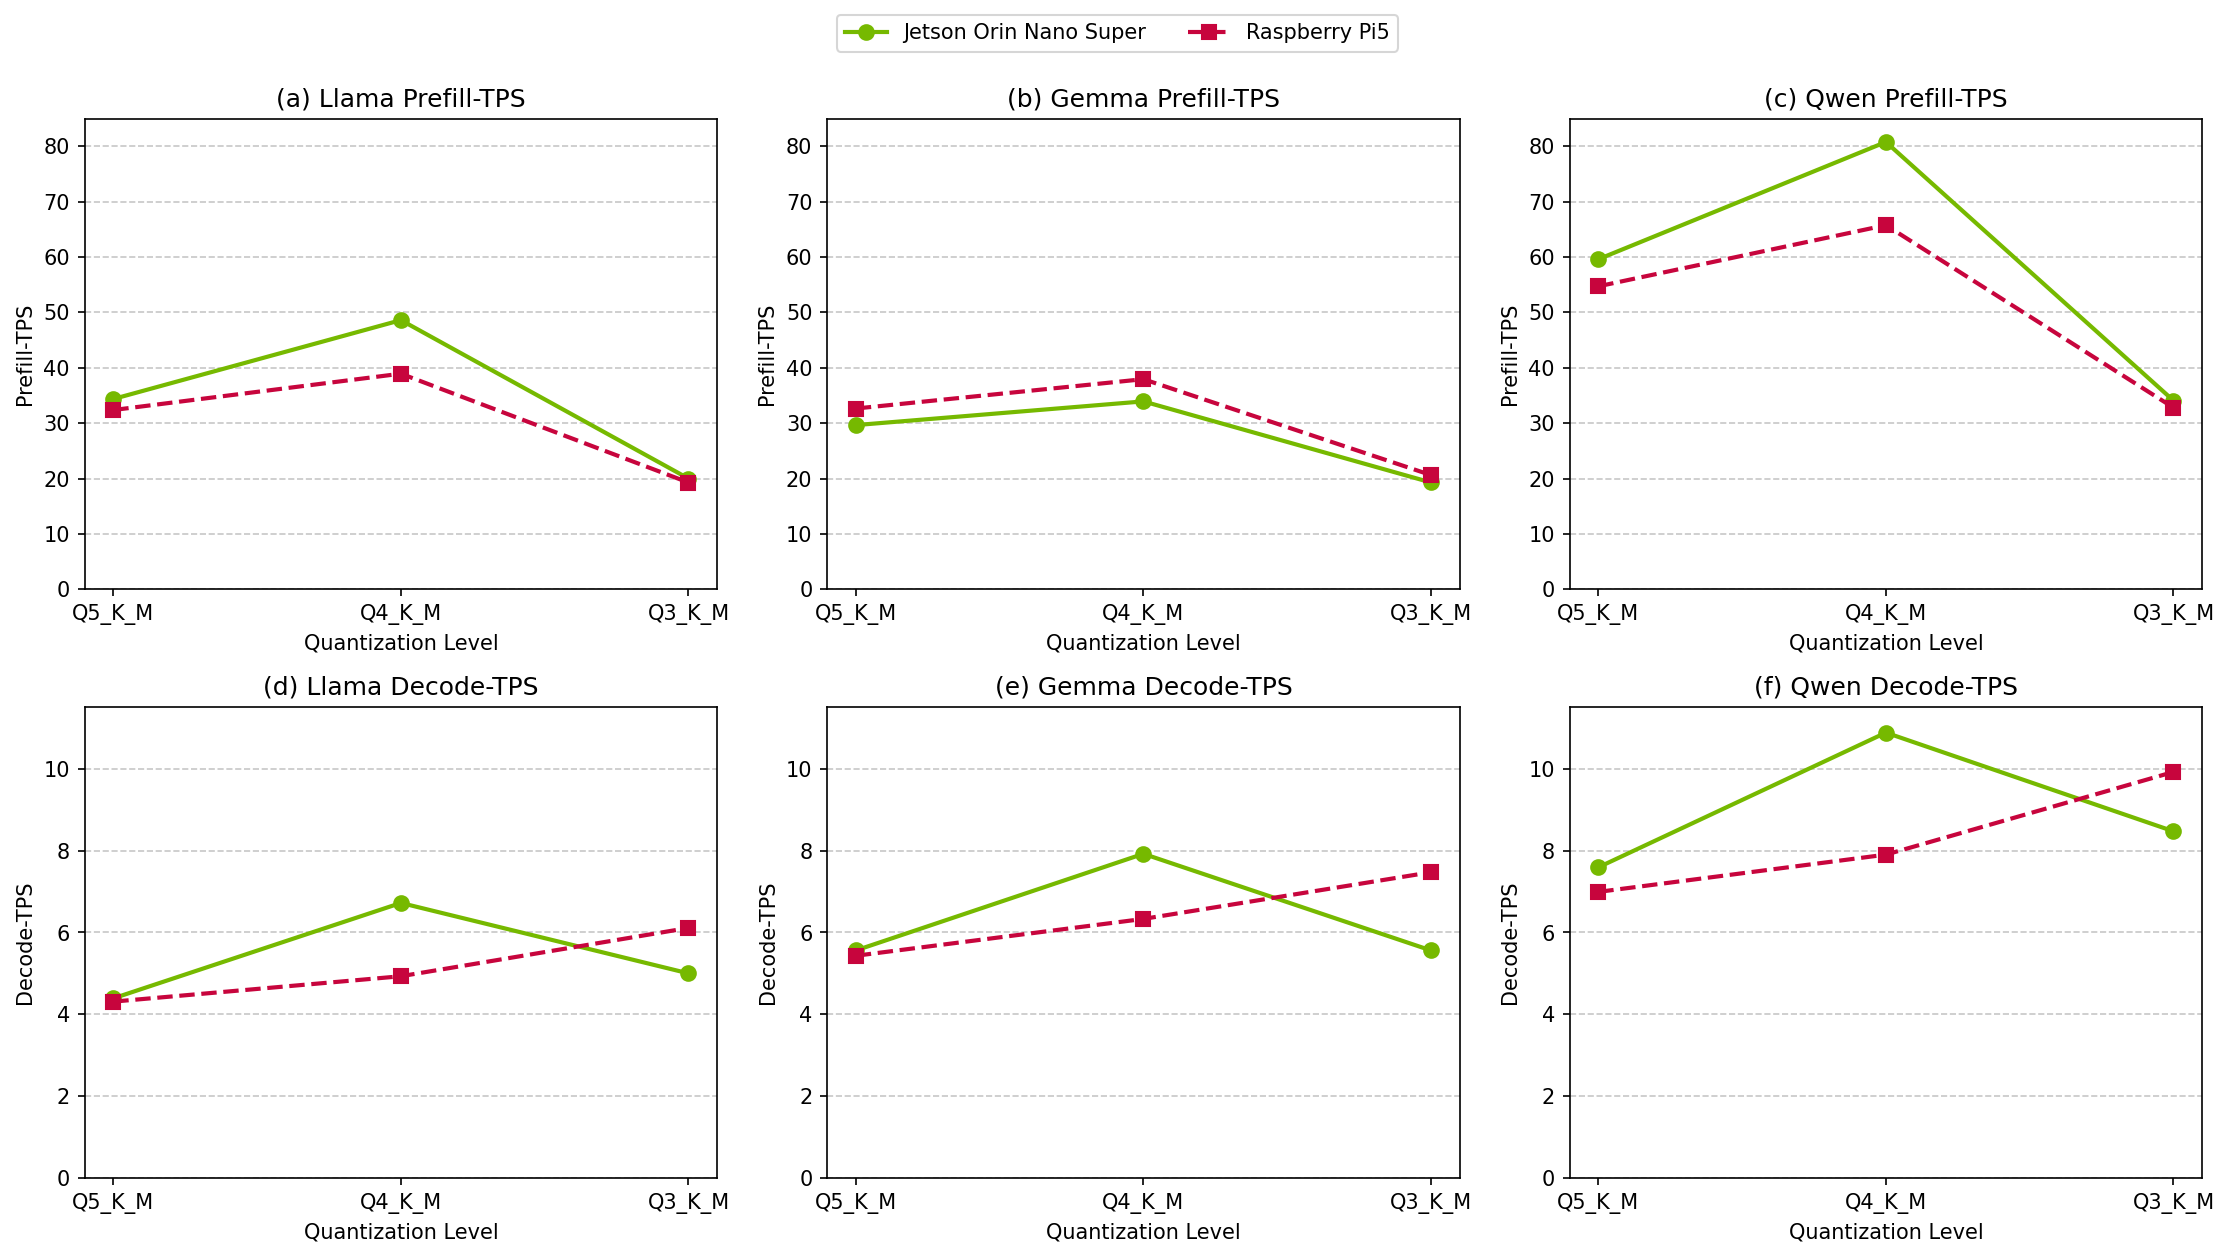

In [ ]:
plot_jetson_vs_pi_tps()

In [ ]:
def plot_jetson_vs_pi_tps_2():

    quant_levels = ['Q5_K_M', 'Q4_K_M', 'Q3_K_M']

    # ==========================================
    # Jetson Data
    # ==========================================
    jetson = {
        'Llama-3.2-3B-Instruct': {'P': [34.36, 48.6, 20],    'D': [4.39, 6.72, 5]},
        'Gemma-4-E2B-it': {'P': [29.65, 33.93, 19.29],'D': [5.56, 7.92, 5.56]},
        'Qwen3-1.7B':  {'P': [59.59, 80.76, 34.07],'D': [7.59, 10.88, 8.47]}
    }

    # ==========================================
    # Raspberry Pi Data
    # ==========================================
    pi = {
        'Llama-3.2-3B-Instruct': {'P': [32.37, 38.93, 19.28],'D': [4.31, 4.93, 6.11]},
        'Gemma-4-E2B-it': {'P': [32.64, 37.94, 20.63],'D': [5.43, 6.33, 7.47]},
        'Qwen3-1.7B':  {'P': [54.7, 65.74, 32.8],  'D': [6.99, 7.9, 9.92]}
    }

    # ==========================================
    # 화살표 시작/끝 좌표 설정
    # ==========================================
    arrow_coords = {
        'Prefill': {
            'Llama-3.2-3B-Instruct': [ ((1.1, 50), (1.28, 45)), ((1.06, 34), (1.28, 30))],
            'Gemma-4-E2B-it': [ ((1.13, 40), (1.31, 37)), ((1.1, 29), (1.28, 26))],
            'Qwen3-1.7B':  [ ((1.1, 82.5), (1.25, 75.7)), ((1, 60), (1.18, 54.5)) ]
        },
        'Decode': {
            'Llama-3.2-3B-Instruct': [ ((1.03, 7.2), (1.22, 6.8))],
            'Gemma-4-E2B-it': [ ((1.1, 8.25), (1.28, 7.8)) ],
            'Qwen3-1.7B':  [ ((1.1, 11.2),(1.28, 10.75)) ]
        }
    }

    # ==========================================
    # Q3_K_M 라즈베리파이 전용 큰 화살표+텍스트 (Decode)
    # ==========================================
    text_arrow_coords = {
        'Llama-3.2-3B-Instruct': ((1.55, 2), (2.0, 6.11), 'CPU outperforms GPU'),
        'Gemma-4-E2B-it': ((1.55, 2.5), (2.0, 7.47), 'CPU outperforms GPU'),
        'Qwen3-1.7B':  ((1.55, 4), (2.0, 9.92), 'CPU outperforms GPU')
    }

    text_arrow_x = {
        'Gemma-4-E2B-it': (0.6, 48, 'CPU outperforms GPU'),
    }

    prefill_extra_texts = {
        'Llama-3.2-3B-Instruct': (1.66, 52, 'Dequantization Overhead'),
        'Gemma-4-E2B-it': (1.66, 43, 'Dequantization Overhead'),
        'Qwen3-1.7B':  (1.66, 74, 'Dequantization Overhead')
    }

    decode_extra_texts = {
        'Llama-3.2-3B-Instruct': (1.60, 7.4, 'Dequantization Overhead'),
        'Gemma-4-E2B-it': (1.60, 8.5, 'Dequantization Overhead'),
        'Qwen3-1.7B':  (1.66, 11.25, 'Dequantization Overhead')
    }

    # 화살표 스타일
    arrow_style = dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=1.5, mutation_scale=10)
    arrow_style_large = dict(facecolor='black', edgecolor='black', arrowstyle='->', lw=2.5, mutation_scale=20)

    # ==========================================
    # subplot 생성
    # ==========================================
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

    jetson_color = '#76B900'
    pi_color = '#c7053d'
    models = ['Llama-3.2-3B-Instruct', 'Gemma-4-E2B-it', 'Qwen3-1.7B']

    # ==========================================
    # 첫 번째 행: Prefill TPS
    # ==========================================
    for idx, model in enumerate(models):
        ax = axes[0, idx]
        ax.plot(quant_levels, jetson[model]['P'], marker='o', linewidth=2, markersize=7, color=jetson_color, label='Jetson Orin Nano Super')
        ax.plot(quant_levels, pi[model]['P'], marker='s', linewidth=2, markersize=7, linestyle='--', color=pi_color, label='Raspberry Pi5')

        ax.set_title(f'({chr(97+idx)}) {model} Avg Prefill-TPS', y=-0.25)
        ax.set_xlabel('Quantization Level')
        ax.set_ylabel('Prefill-TPS')
        ax.set_ylim(0, 85)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # 시작/끝 좌표 화살표 추가
        for (start_xy, end_xy) in arrow_coords['Prefill'][model]:
            ax.annotate('', xy=end_xy, xytext=start_xy, arrowprops=arrow_style)

        if model in text_arrow_x:
            t_x, t_y, extra_text = text_arrow_x[model]
            ax.text(t_x, t_y, extra_text,
                    fontsize=11,
                    color='black',
                    fontweight='bold',
                    ha='center', va='center')

        # 3. 독립 텍스트 추가
        if model in decode_extra_texts:
            t_x, t_y, extra_text = prefill_extra_texts[model]
            ax.text(t_x, t_y, extra_text,
                    fontsize=8,
                    color='blue',
                    fontweight='bold',
                    ha='center', va='center')

    # ==========================================
    # 두 번째 행: Decode TPS
    # ==========================================
    for idx, model in enumerate(models):
        ax = axes[1, idx]
        ax.plot(quant_levels, jetson[model]['D'], marker='o', linewidth=2, markersize=7, color=jetson_color, label='Jetson Orin Nano Super')
        ax.plot(quant_levels, pi[model]['D'], marker='s', linewidth=2, markersize=7, linestyle='--', color=pi_color, label='Raspberry Pi5')

        ax.set_title(f'({chr(100+idx)}) {model} Avg Decode-TPS', y=-0.25)
        ax.set_xlabel('Quantization Level')
        ax.set_ylabel('Decode-TPS')
        ax.set_ylim(0, 11.5)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # 1. 시작/끝 좌표 일반 화살표 추가
        for (start_xy, end_xy) in arrow_coords['Decode'][model]:
            ax.annotate('', xy=end_xy, xytext=start_xy, arrowprops=arrow_style)

        # 2. 큰 화살표와 텍스트 추가
        if model in text_arrow_coords:
            text_xy, end_xy, text_str = text_arrow_coords[model]
            ax.annotate(text_str, xy=end_xy, xytext=text_xy, arrowprops=arrow_style_large,
                        fontsize=11, fontweight='bold', ha='center', va='center')

        # 3. 독립 텍스트 추가
        if model in decode_extra_texts:
            t_x, t_y, extra_text = decode_extra_texts[model]
            ax.text(t_x, t_y, extra_text,
                    fontsize=8,
                    color='blue',
                    fontweight='bold',
                    ha='center', va='center')

    # ==========================================
    # Layout
    # ==========================================
    plt.tight_layout(h_pad=2.5)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

    plt.savefig('jetson_vs_pi_tps.png', bbox_inches='tight')
    plt.show()

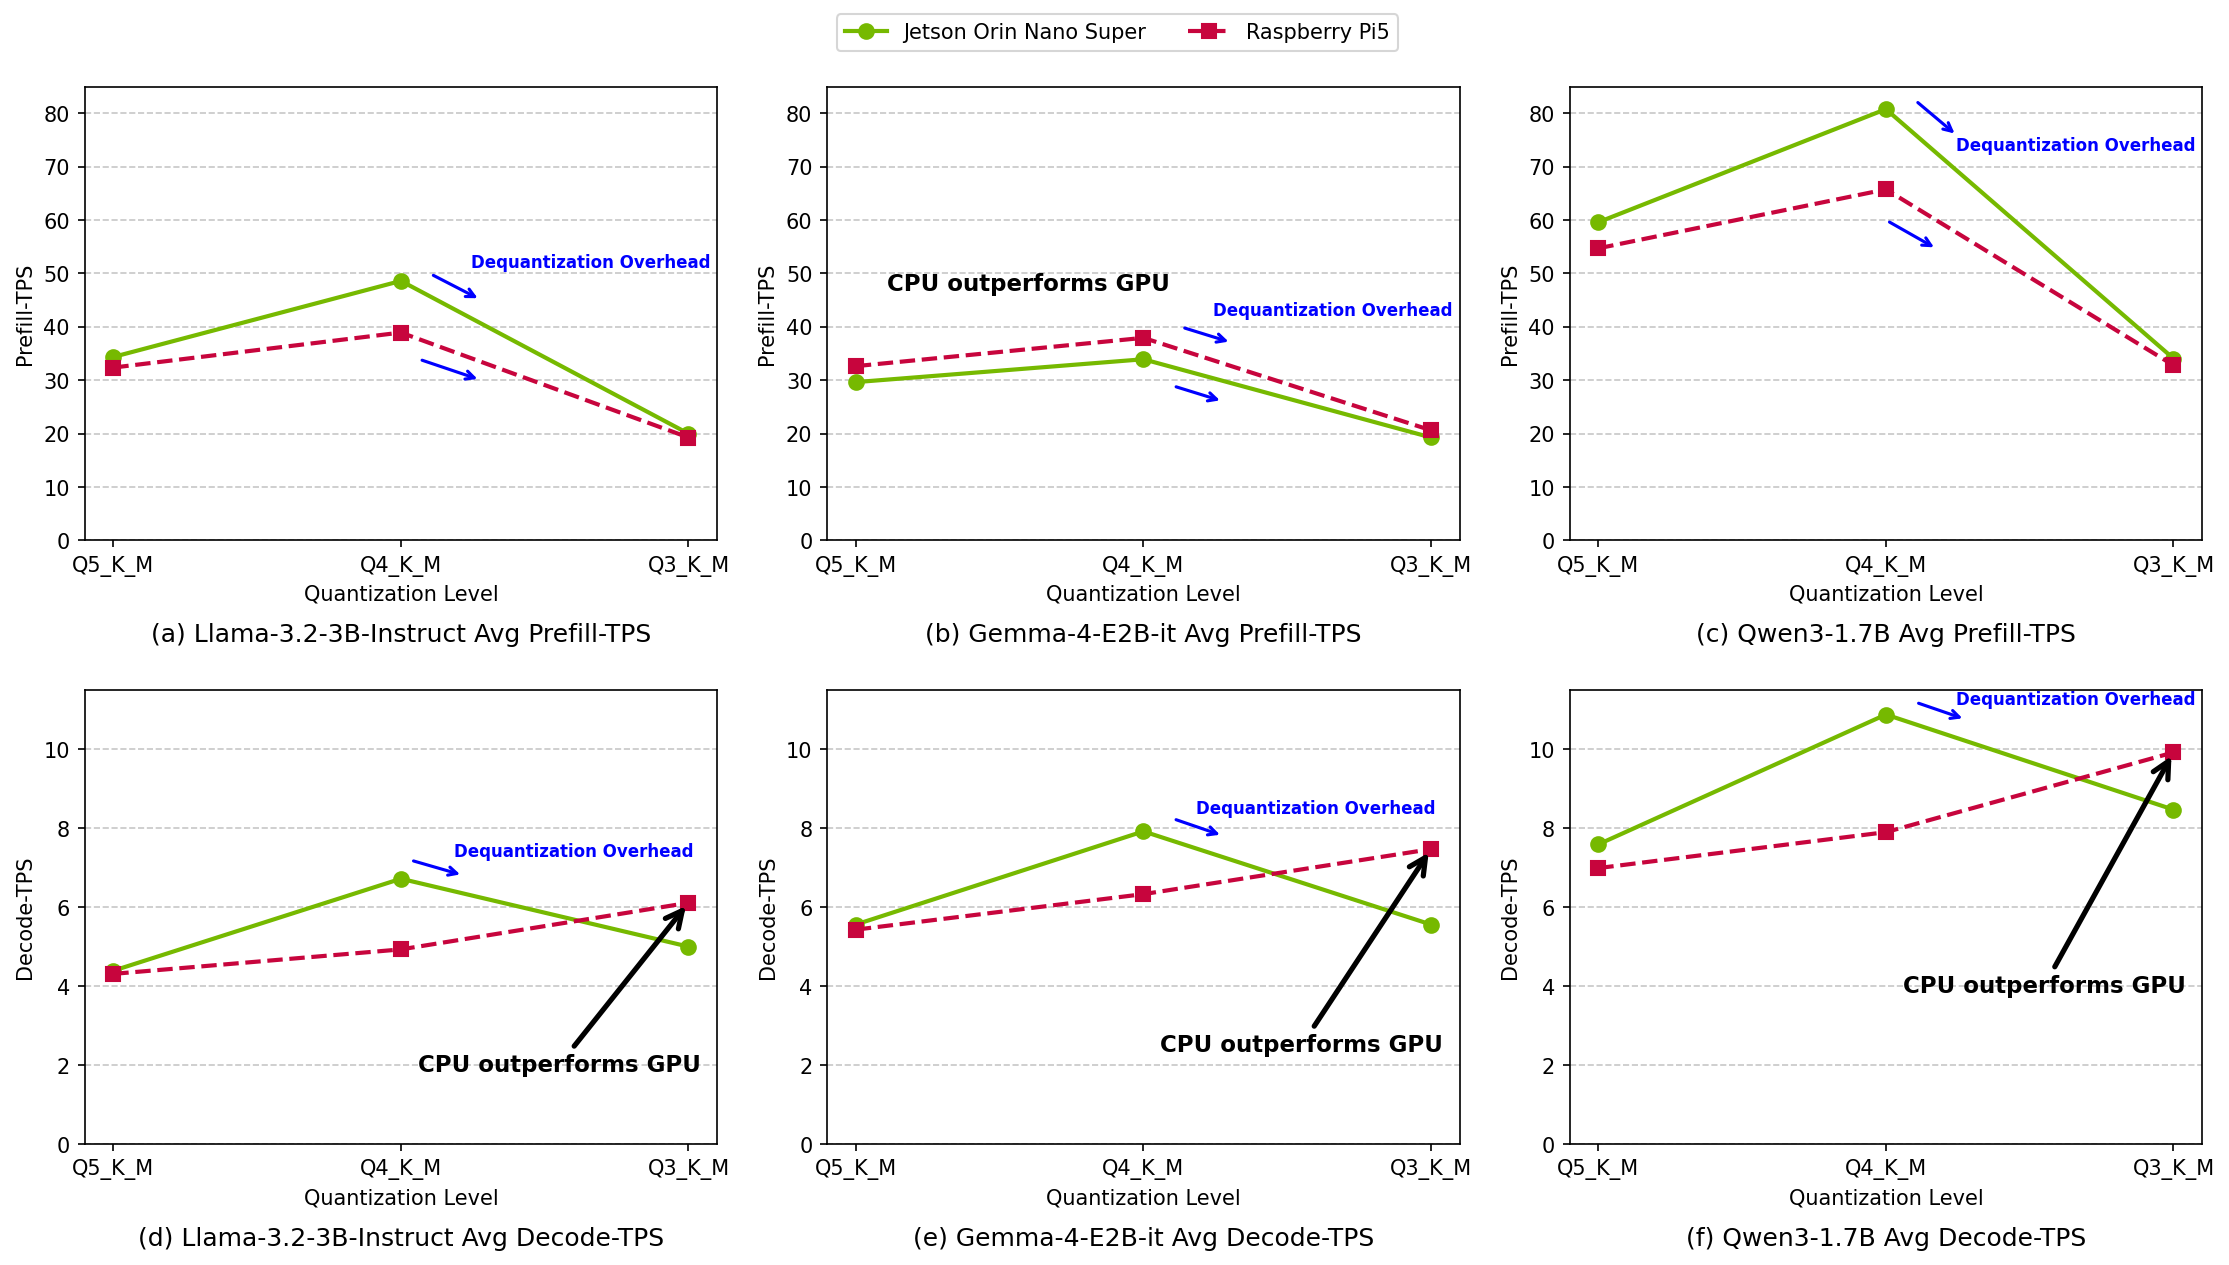

In [ ]:
plot_jetson_vs_pi_tps_2()

In [ ]:
def plot_combined_memory_figure():
    m_tokens = ['128', '256', '512']
    x = np.arange(len(m_tokens))
    width = 0.25

    # ==========================================
    # 1. Jetson Data (Top Row)
    # ==========================================
    jetson_data = {
        'Q5_K_M': ([3075.4, 3641.5, 3062.8], [5147.5, 2444.9, 2441.6], [2049.9, 2259.2, 2791.7]),
        'Q4_K_M': ([4244.8, 4251.7, 4145.2], [4198.9, 3226.3, 3255], [2591.3, 2548.5, 2607.7]),
        'Q3_K_M': ([2909.8, 2912.5, 2912.7], [2933.4, 2640.3, 2510.4], [1886.5, 1874.6, 1927])
    }

    # ==========================================
    # 2. Raspberry Pi Data (Bottom Row)
    # ==========================================
    pi_data = {
        'Q5_K_M': ([4925.1, 4925.7, 4925.7], [5171, 4975.4, 5170.4], [2908.7, 2908.6, 2908.5]),
        'Q4_K_M': ([4350.6, 4350.9, 4348.3], [4692.2, 4684, 4694.3], [2623.1, 2623, 2623]),
        'Q3_K_M': ([3008.7, 3002.4, 3006], [3235.7, 3204.2, 3210.5], [1948.7, 1948.5, 1948.5])
    }

    # 설정값 리스트
    environments = [jetson_data, pi_data]
    quant_levels = ['Q5_K_M', 'Q4_K_M', 'Q3_K_M']
    env_names = ['Jetson Orin Nano Super', 'Raspberry Pi5']

    models = ['Llama-3.2-3B-Instruct', 'Gemma-4-E2B-it', 'Qwen3-1.7B']
    colors = ['#4C72B0', '#DD8452', '#55A868']

    # ==========================================
    # 2행 3열 subplot 생성 (크기 조정)
    # ==========================================
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

    for row_idx, env_data in enumerate(environments):
        for col_idx, quant in enumerate(quant_levels):
            ax = axes[row_idx, col_idx]

            # 각 모델별 데이터 추출 (Llama, Gemma, Qwen 순서)
            llama_mem, gemma_mem, qwen_mem = env_data[quant]

            # Bar 차트 그리기
            ax.bar(x - width, llama_mem, width, label=models[0], color=colors[0])
            ax.bar(x, gemma_mem, width, label=models[1], color=colors[1])
            ax.bar(x + width, qwen_mem, width, label=models[2], color=colors[2])

            # X축 설정
            ax.set_xticks(x)
            ax.set_xticklabels(m_tokens)
            ax.set_xlabel('Max Tokens')

            # Y축 설정 (첫 번째 열에만 라벨 표시)
            if col_idx == 0:
                ax.set_ylabel('Peak Memory (MB)')
            ax.set_ylim(0, 5500)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

            # ==========================================
            # 캡션(제목)을 아래로 이동
            # (a) ~ (f) 형식으로 자동 네이밍
            # ==========================================
            caption_idx = row_idx * 3 + col_idx
            caption_text = f'({chr(97 + caption_idx)}) {env_names[row_idx]} - {quant}'

            # y값을 음수로 주어 x축 라벨 밑으로 내림
            ax.set_title(caption_text, y=-0.25)

    # ==========================================
    # 공통 범례 및 레이아웃 정리
    # ==========================================
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center',
               ncol=3,
               bbox_to_anchor=(0.5, 1.05))

    # 위아래 그래프 겹침 방지를 위해 높이 간격(h_pad) 확보
    plt.tight_layout(h_pad=2.5)
    plt.savefig('figure1_memory_combined.png', bbox_inches='tight')
    plt.show()

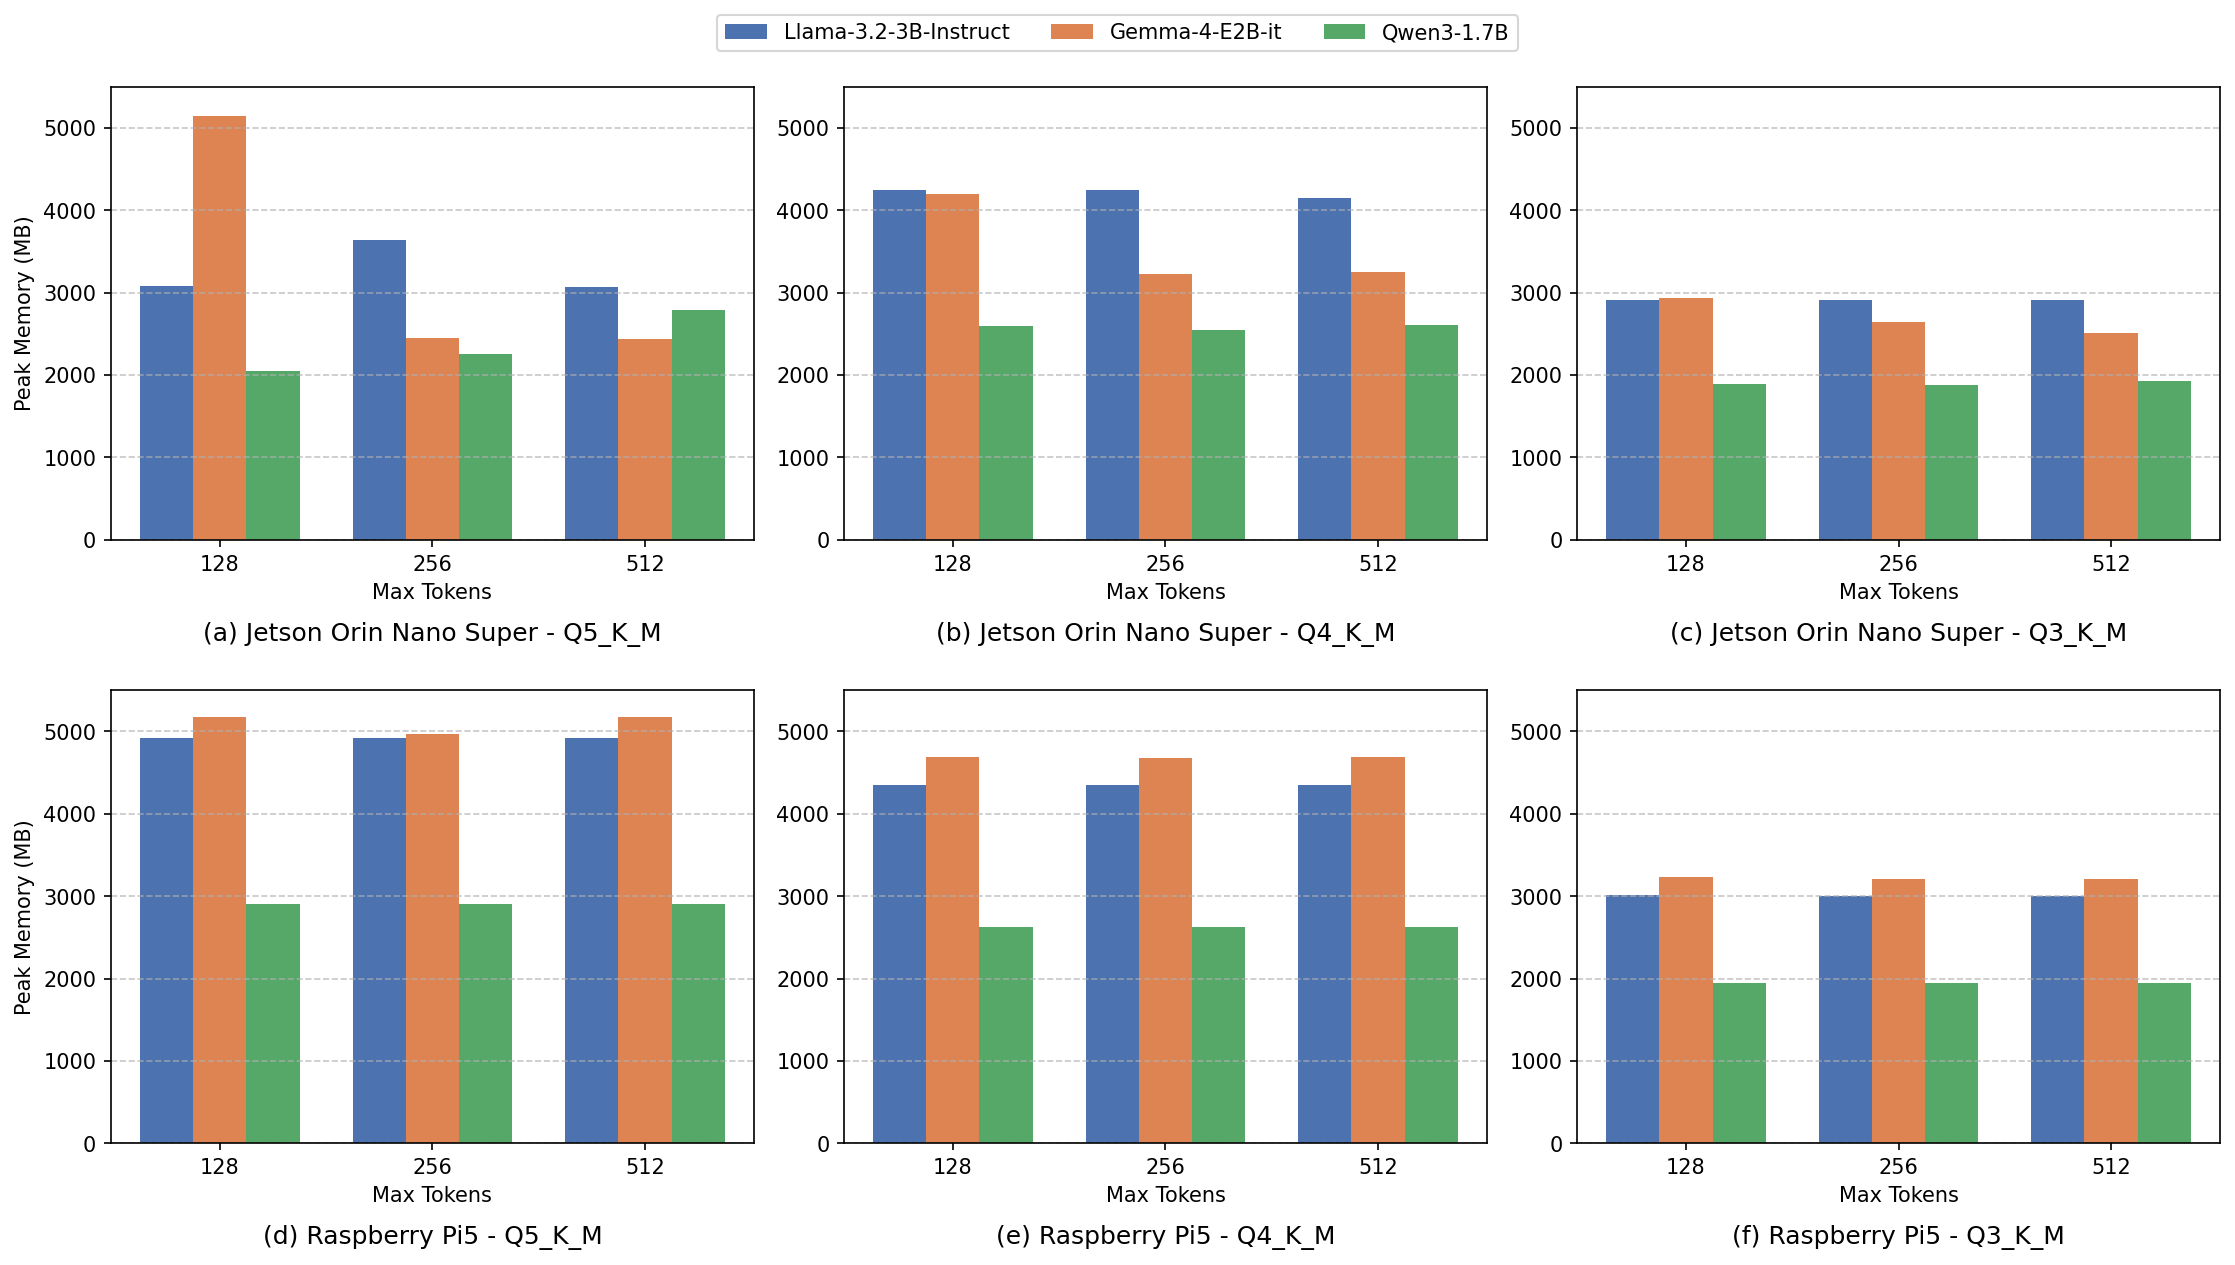

In [ ]:
plot_combined_memory_figure()

In [ ]:
def plot_ttft_comparison():
    quant_levels = ['Q5_K_M', 'Q4_K_M', 'Q3_K_M']

    # ==========================================
    # 데이터 전처리: M_tokens (128, 256, 512)의 TTFT 평균값 계산
    # ==========================================

    jetson_ttft = {
        'Llama-3.2-3B-Instruct': [4.07, 2.76, 6.74],
        'Gemma-4-E2B-it': [4.41, 3.88, 6.31],
        'Qwen3-1.7B': [2.01, 1.47, 3.51]
    }

    pi_ttft = {
        'Llama-3.2-3B-Instruct': [4.15, 3.45, 6.99],
        'Gemma-4-E2B-it': [3.63, 3.12, 5.75],
        'Qwen3-1.7B': [2.18, 1.81, 3.65]
    }

    text_arrow_x = {
        'Gemma-4-E2B-it': (0.6, 2, 'CPU outperforms GPU'),
    }

    arrow_coords = {
            'Llama-3.2-3B-Instruct': [ ((1, 3.8), (1.15, 4.4)), ((1.1, 2.6), (1.25, 3.2))],
            'Gemma-4-E2B-it': [ ((1, 4.2), (1.15, 4.62)), ((1.1, 3), (1.25, 3.4))],
            'Qwen3-1.7B':  [ ((1, 2.2), (1.18, 2.56)), ((1.1, 1.3), (1.3, 1.7)) ]
    }

    dequantization_overhead_texts = {
            'Llama-3.2-3B-Instruct': (1.60, 2.5, 'Dequantization Overhead'),
            'Gemma-4-E2B-it': (1.60, 2.8, 'Dequantization Overhead'),
            'Qwen3-1.7B':  (1.6, 1.2, 'Dequantization Overhead')
    }

    arrow_style = dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=1.5, mutation_scale=10)

    models = ['Llama-3.2-3B-Instruct', 'Gemma-4-E2B-it', 'Qwen3-1.7B']

    # 색상 설정 (기존 TPS 그래프 스타일과 통일)
    jetson_color = '#76B900'
    pi_color = '#c7053d'

    # ==========================================
    # 1행 3열 subplot 생성
    # ==========================================
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

    for idx, model in enumerate(models):
        ax = axes[idx]

        # Jetson 그래프 그리기
        ax.plot(
            quant_levels, jetson_ttft[model],
            marker='o', linewidth=2, markersize=7,
            color=jetson_color, label='Jetson Orin Nano Super'
        )

        # Pi 그래프 그리기
        ax.plot(
            quant_levels, pi_ttft[model],
            marker='s', linewidth=2, markersize=7, linestyle='--',
            color=pi_color, label='Raspberry Pi 5'
        )

        # 특정 텍스트 추가
        if model in text_arrow_x:
            t_x, t_y, extra_text = text_arrow_x[model]
            ax.text(t_x, t_y, extra_text,
                    fontsize=11,
                    color='black',
                    fontweight='bold',
                    ha='center', va='center')

        if model in dequantization_overhead_texts:
            t_x, t_y, extra_text = dequantization_overhead_texts[model]
            ax.text(t_x, t_y, extra_text,
                    fontsize=8,
                    color='blue',
                    fontweight='bold',
                    ha='center', va='center')

        # ==========================================
        # ★ 추가: 원점(0,0)을 향하는 두껍고 짧은 붉은색 화살표 (225도 방향)
        # ==========================================
        ax.annotate('Best',
                    xy=(-0.1, 0),             # 화살표 끝(머리)이 가리키는 위치 (원점)
                    xytext=(0.1, 0.5),     # 텍스트의 위치 (이 값을 조절해 화살표의 길이와 각도를 미세조정)
                    fontsize=12,
                    color='red',
                    fontweight='bold',
                    ha='center', va='center',
                    arrowprops=dict(
                        facecolor='red',   # 화살표 내부 색상
                        edgecolor='red',   # 화살표 테두리 색상
                        width=4,           # 화살표 몸통 두께
                        headwidth=10,      # 화살촉 너비
                        headlength=5,     # 화살촉 길이
                        shrink=0.05        # 끝점과 원점 사이의 약간의 여백
                    ))

        # 이전처럼 제목을 그래프 밑(x축 라벨 밑)에 캡션 형태로 배치
        caption_text = f'({chr(97 + idx)}) {model} Avg TTFT'
        ax.set_title(caption_text, y=-0.25)

        ax.set_xlabel('Quantization Level')
        ax.set_ylabel('Avg TTFT (s)')

        # Y축 범위를 통일시켜 모델 간 비교를 쉽게 함
        ax.set_ylim(0, 8.0)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        for (start_xy, end_xy) in arrow_coords[model]:
            ax.annotate('', xy=end_xy, xytext=start_xy, arrowprops=arrow_style)

    # ==========================================
    # 공통 범례 및 레이아웃 정리
    # ==========================================
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center',
               ncol=2,
               bbox_to_anchor=(0.5, 1.10))

    # 캡션(제목)을 위한 하단 여백 확보
    plt.tight_layout(h_pad=2.5)

    plt.subplots_adjust(top=1)

    plt.savefig('ttft_comparison.png', bbox_inches='tight')
    plt.show()

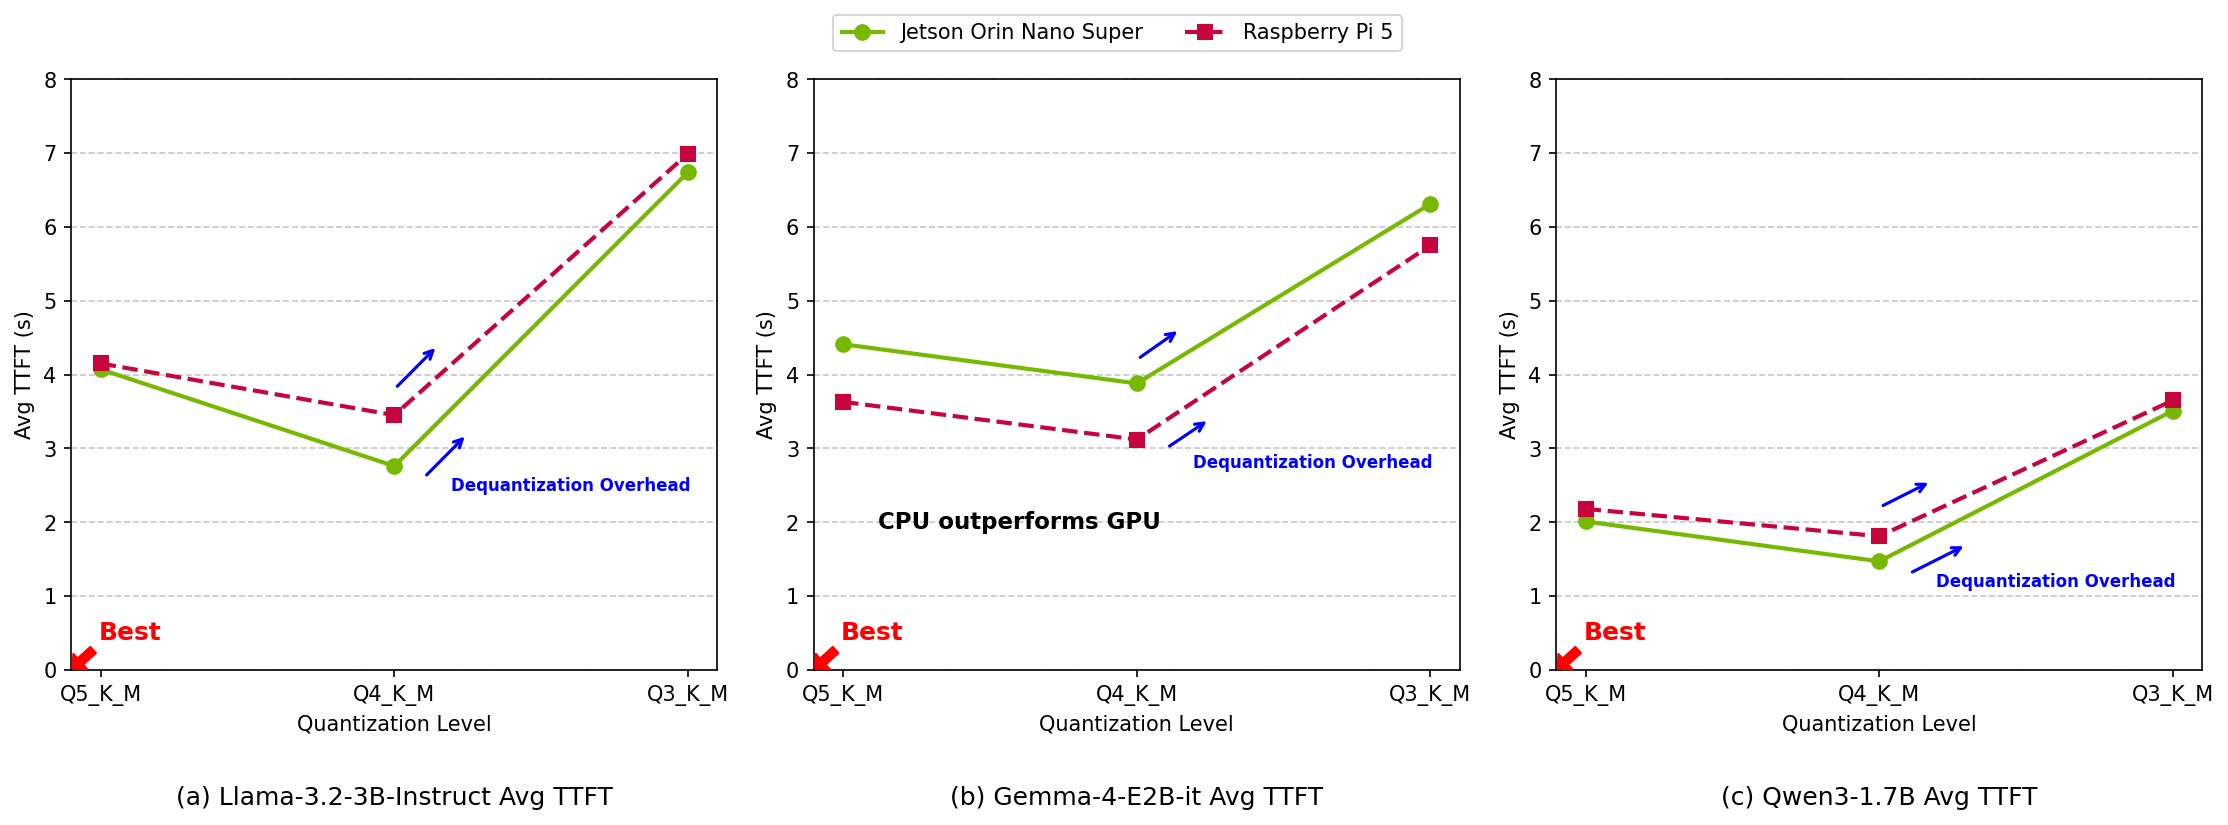

In [ ]:
plot_ttft_comparison()